**Objetivos:** 
- Trabalhar com categorias ordinais (Péssimo a Ótimo).
- Comparar gráficos ordenados naturalmente vs. ordenados por frequência.
- Calcular proporções acumuladas e interpretar.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

satisfacao = ["Péssimo", "Ruim", "Regular", "Bom", "Ótimo"]
frequencia = np.array([5, 9, 21, 31, 14])

# a) Calculando os percentuais
total_usuarios = frequencia.sum() # Sabemos que é 80
percentuais = 100 * frequencia / total_usuarios

# Exibindo como tabela
tabela = pd.DataFrame({
    "Frequência": frequencia, 
    "Percentual (%)": percentuais
}, index=satisfacao)

display(tabela.round(2))

,Frequência,Percentual (%)
Péssimo,5,6.25
Ruim,9,11.25
Regular,21,26.25
Bom,31,38.75
Ótimo,14,17.50


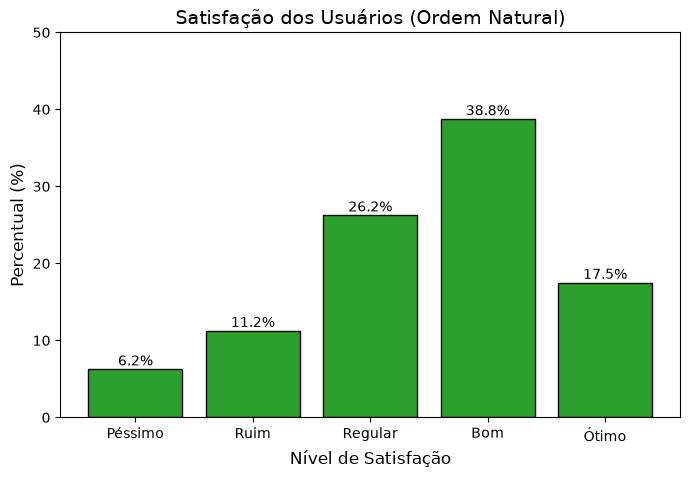

In [3]:
# b) Gráfico preservando a ordem natural das categorias
fig, ax = plt.subplots(figsize=(8, 5))
barras_nat = ax.bar(satisfacao, percentuais, color='#2CA02C', edgecolor='black')

ax.set_title("Satisfação dos Usuários (Ordem Natural)", fontsize=14)
ax.set_xlabel("Nível de Satisfação", fontsize=12)
ax.set_ylabel("Percentual (%)", fontsize=12)

for barra in barras_nat:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 0.5, f'{altura:.1f}%', ha='center')

ax.set_ylim(0, 50)
plt.show()

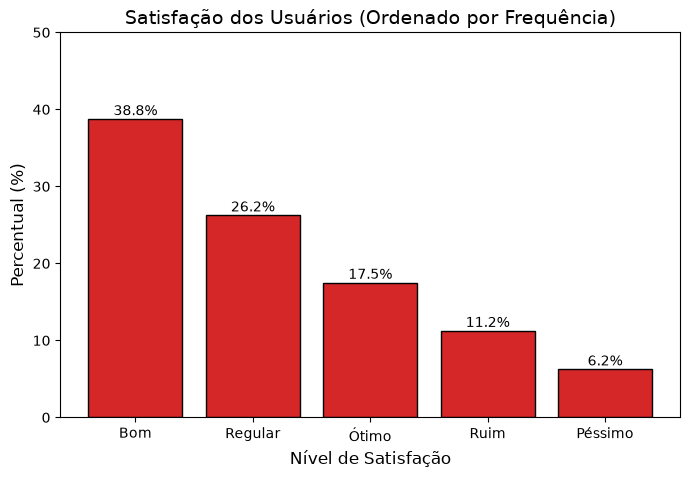

In [ ]:
# c) Gráfico ordenando as barras da maior para a menor frequência
indices_ordenados = np.argsort(frequencia)[::-1]
satisfacao_ord = np.array(satisfacao)[indices_ordenados]
percentuais_ord = percentuais[indices_ordenados]

fig, ax = plt.subplots(figsize=(8, 5))
barras_ord = ax.bar(satisfacao_ord, percentuais_ord, color='#D62728', edgecolor='black')

ax.set_title("Satisfação dos Usuários (Ordenado por Frequência)", fontsize=14)
ax.set_xlabel("Nível de Satisfação", fontsize=12)
ax.set_ylabel("Percentual (%)", fontsize=12)

for barra in barras_ord:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, altura + 0.5, f'{altura:.1f}%', ha='center')

ax.set_ylim(0, 50)
plt.show()

**d) Compare as duas representações. Qual delas é mais apropriada para uma variável ordinal? Explique.**

A primeira representação (ordem natural) é, sem dúvida, a correta e mais apropriada. Como a variável é ordinal, existe uma hierarquia lógica (do pior para o melhor). Quando preservamos essa ordem, o leitor consegue visualizar a "curva" da satisfação, percebendo imediatamente se os dados estão inclinados para o lado positivo ou negativo. 

In [ ]:
# e) Cálculo das proporções 

prop_bom_otimo = percentuais[3] + percentuais[4]

prop_regular_inferior = percentuais[0] + percentuais[1] + percentuais[2]

print(f"Proporção de usuários (Bom ou Ótimo): {prop_bom_otimo:.1f}%")
print(f"Proporção de usuários (Regular ou inferior): {prop_regular_inferior:.1f}%")

Proporção de usuários (Bom ou Ótimo): 56.2%
Proporção de usuários (Regular ou inferior): 43.8%


**f) Escreva uma interpretação dos resultados.**

O serviço foi bem recebido pela maioria, com mais da metade dos usuários (56,2%) avaliando-o de forma positiva (Bom ou Ótimo). No entanto, há um ponto de atenção significativo: uma parcela considerável de 43,8% classificou o serviço como Regular ou pior. Isso indica que, embora o produto central funcione para a maioria, existem gargalos ou problemas de experiência que precisam ser investigados para converter esses usuários medianos/insatisfeitos em promotores.